# Philippine Household Income Classification
### End-to-End Machine Learning Pipeline
**Dataset:** Family Income and Expenditure Survey (FIES) — Philippines  

**Goal:** Predict whether a household earns **above or below the median monthly income** based on their spending habits, household profile, and asset ownership.

**Why this matters:** The Philippines has significant income inequality. If we can predict a household's income class from observable characteristics (house type, appliances owned, education level, etc.), policymakers and social programs can better identify who needs support — even without direct income data.

**Workflow:**
1. Load & Explore the Data (EDA)
2. Visualize Key Patterns
3. Engineer the Target Variable
4. Clean & Preprocess
5. Train ML Models
6. Evaluate & Compare
7. Interpret Results

## SECTION 1: Import Libraries
Think of these as our toolbox. Each library does a specific job — pandas handles data tables, matplotlib/seaborn draw charts, and sklearn builds and evaluates our machine learning models.

In [94]:
# --- DATA HANDLING ---
import pandas as pd        # For working with tables/spreadsheets
import numpy as np         # For math operations

# --- VISUALIZATION ---
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # Prettier, higher-level charts

# --- MACHINE LEARNING: CLASSIFICATION ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# --- MACHINE LEARNING: REGRESSION ---
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# --- EVALUATION METRICS ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# --- SETTINGS ---
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully!')

%matplotlib inline


All libraries imported successfully!


## SECTION 2: Load the Dataset
We load our CSV file into a **DataFrame** — basically a table in Python. Upload your `final_edited_file.csv` to the Colab session files (left sidebar → Files icon → Upload) before running this cell.

In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
# Load the CSV file into a DataFrame called 'df'
df = pd.read_csv('/content/drive/MyDrive/Uplift - Python for Data and AI/0413 Model Training Activity (Basic Machine Learning)/Family Income and Expenditure_edited.csv')

# Drop the unnamed index column that sometimes comes with CSV exports
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# ─────────────────────────────────────────────────────────────────────────────
# CREATE TARGET VARIABLE HERE — before any columns are dropped
# We do this immediately after loading so re-running any later cell won't break it.
# Target: 1 = Above Median Monthly Income, 0 = At or Below Median
# ─────────────────────────────────────────────────────────────────────────────
median_income = df['Monthly Income'].median()
df['Income_Class'] = (df['Monthly Income'] > median_income).astype(int)

print(f'Dataset loaded successfully!')
print(f'   Rows         : {df.shape[0]:,}')
print(f'   Columns      : {df.shape[1]}')
print(f'   Median Income: ₱{median_income:,.2f}/month')
print(f'   Target created → Income_Class  (0 = below median, 1 = above median)')


Dataset loaded successfully!
   Rows         : 41,544
   Columns      : 64
   Median Income: ₱13,673.29/month
   Target created → Income_Class  (0 = below median, 1 = above median)


## SECTION 3: Exploratory Data Analysis (EDA)
Before building any model, we need to **understand our data**. EDA answers questions like: What do the first few rows look like? Are there missing values? What is the typical income? What types of data do we have?

Think of EDA as getting to know your dataset before you start working with it.

In [97]:
# Preview the first 5 rows
# This shows us what a 'household record' actually looks like
print('=== FIRST 5 ROWS ===')
df.head()

=== FIRST 5 ROWS ===


,Annual Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle,Monthly Income,Total Expenditure,Total Monthly Expenditure,Income_Class
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,0,2,1,0,0,1,40027.67,327030,27252.50,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,3,1,0,0,2,16519.58,211888,17657.33,1
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,6898.75,103413,8617.75,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,1,0,0,0,0,8965.75,137279,11439.92,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,0,3,0,0,0,1,15776.83,192202,16016.83,1


In [98]:
# Check column names, data types, and how many values are non-null
# 'object' dtype = text/categorical; 'int64'/'float64' = numeric
print('=== COLUMN INFO ===')
df.info()

=== COLUMN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 64 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Annual Household Income                        41544 non-null  int64  
 1   Region                                         41544 non-null  object 
 2   Total Food Expenditure                         41544 non-null  int64  
 3   Main Source of Income                          41544 non-null  object 
 4   Agricultural Household indicator               41544 non-null  int64  
 5   Bread and Cereals Expenditure                  41544 non-null  int64  
 6   Total Rice Expenditure                         41544 non-null  int64  
 7   Meat Expenditure                               41544 non-null  int64  
 8   Total Fish and  marine products Expenditure    41544 non-null  int64  
 9   Fruit Expenditure             

In [99]:
# Summary statistics for all numeric columns
# This gives us the min, max, average, and spread of every number column
print('=== DESCRIPTIVE STATISTICS ===')
df.describe().T   # .T = transpose so it's easier to read tall

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
Annual Household Income,41544.0,247555.584802,286880.522653,11285.00,104895.00,164079.50,291138.5000,11815988.00
Total Food Expenditure,41544.0,85099.158194,51637.947682,2947.00,51017.25,72985.50,105635.5000,827565.00
Agricultural Household indicator,41544.0,0.429858,0.676666,0.00,0.00,0.00,1.0000,2.00
Bread and Cereals Expenditure,41544.0,25133.723642,13466.482984,0.00,16556.00,23324.00,31439.0000,765864.00
Total Rice Expenditure,41544.0,18195.825005,11727.224350,0.00,11020.00,16620.00,23920.0000,758326.00
Meat Expenditure,41544.0,10540.072574,10497.727757,0.00,3353.75,7332.50,14292.0000,261566.00
Total Fish and marine products Expenditure,41544.0,10529.318337,7812.201613,0.00,5504.00,8695.00,13388.0000,188208.00
Fruit Expenditure,41544.0,2550.474990,2969.752879,0.00,1024.75,1820.00,3100.0000,273769.00
Vegetables Expenditure,41544.0,5006.918568,3300.175236,0.00,2873.00,4314.00,6304.2500,74800.00
Restaurant and hotels Expenditure,41544.0,15436.566075,23705.195929,0.00,1930.00,7314.00,19921.2500,725296.00


In [100]:
# Check for missing values in each column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print('=== MISSING VALUES ===')
if len(missing) == 0:
    print('No missing values found! 🎉')
else:
    print(missing)
    print(f'\nTotal columns with missing data: {len(missing)}')

=== MISSING VALUES ===
Household Head Occupation         7536
Household Head Class of Worker    7536
Toilet Facilities                 1580
dtype: int64

Total columns with missing data: 3


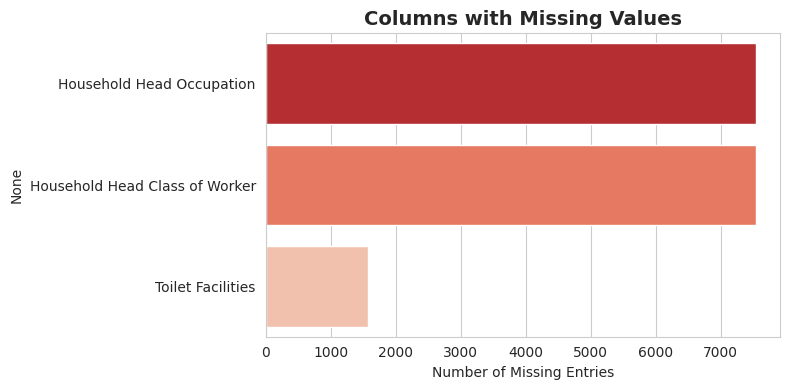


 Observation: Occupation and Class of Worker columns have the most missing data.
   This is expected — households where the head has no job would have no occupation data.


In [101]:
# Visualize missing values as a bar chart
# Only run this if there are missing values
if len(missing) > 0:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing.values, y=missing.index, palette='Reds_r')
    plt.title('Columns with Missing Values', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Missing Entries')
    plt.tight_layout()
    plt.show()
    print('\n Observation: Occupation and Class of Worker columns have the most missing data.')
    print('   This is expected — households where the head has no job would have no occupation data.')
else:
    print('No missing values to plot.')

## SECTION 4: Visualizing Key Patterns
Charts help us see patterns that raw numbers can't easily communicate. Here we look at income distribution, spending patterns, and how different household types compare.

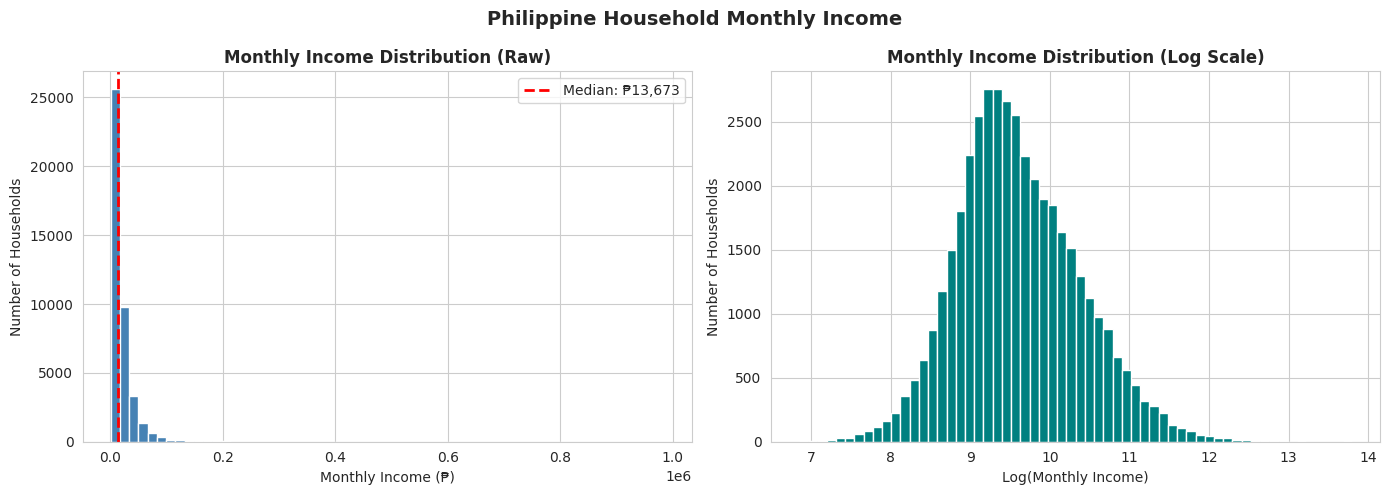


 Observation:
   • Median monthly income: ₱13,673.29
   • Mean monthly income  : ₱20,629.63
   • The mean is much higher than the median — this means a small number of
     very high-income households are pulling the average up (right-skewed data).
   • The log-scale version shows a cleaner bell shape, confirming the skew.


In [102]:
# Monthly Income Distribution
# Most households will cluster at the lower end — this is typical in income data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw distribution
axes[0].hist(df['Monthly Income'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df['Monthly Income'].median(), color='red', linestyle='--', linewidth=2,
                label=f"Median: ₱{df['Monthly Income'].median():,.0f}")
axes[0].set_title('Monthly Income Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Monthly Income (₱)')
axes[0].set_ylabel('Number of Households')
axes[0].legend()

# Right: Log scale — better shows spread when data is skewed
axes[1].hist(np.log1p(df['Monthly Income']), bins=60, color='teal', edgecolor='white')
axes[1].set_title('Monthly Income Distribution (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Log(Monthly Income)')
axes[1].set_ylabel('Number of Households')

plt.suptitle('Philippine Household Monthly Income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Observation:")
print(f"   • Median monthly income: ₱{df['Monthly Income'].median():,.2f}")
print(f"   • Mean monthly income  : ₱{df['Monthly Income'].mean():,.2f}")
print(f"   • The mean is much higher than the median — this means a small number of")
print(f"     very high-income households are pulling the average up (right-skewed data).")
print(f"   • The log-scale version shows a cleaner bell shape, confirming the skew.")

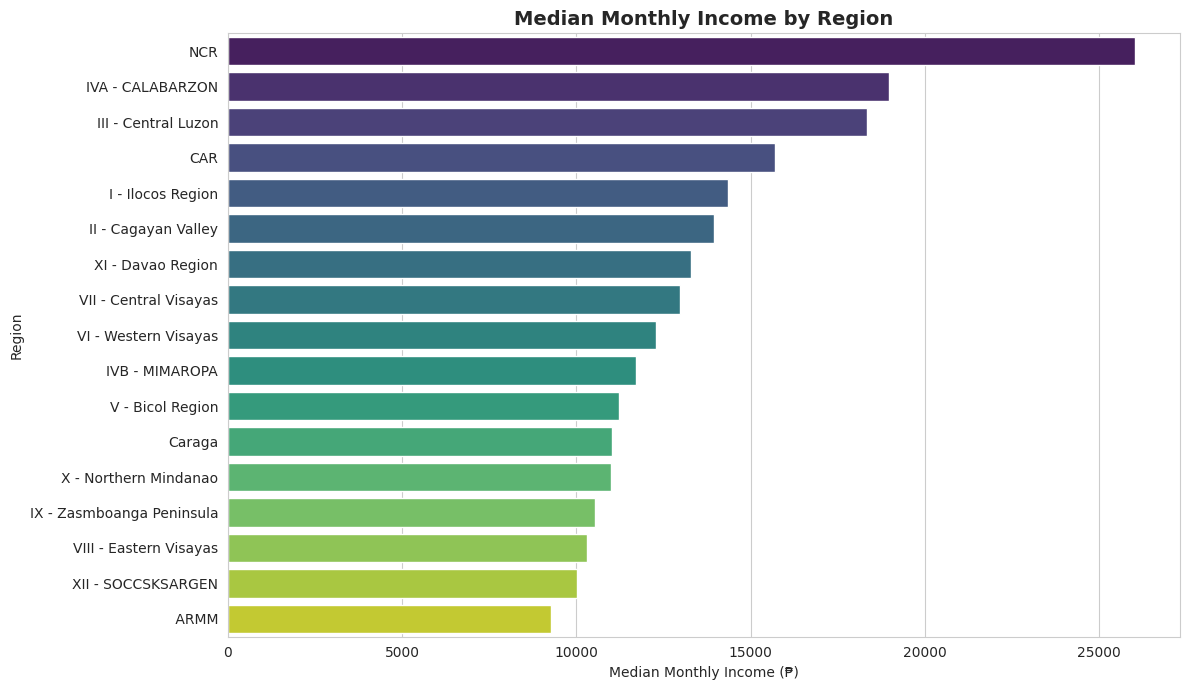


 Observation:
   Regions with higher urbanization (NCR, CALABARZON) tend to have higher median incomes.
   Mindanao and BARMM regions generally appear at the lower end — consistent with
   known development gaps in the Philippines.


In [103]:
# Median Income by Region
# Which regions have the highest/lowest household income?

region_income = (
    df.groupby('Region')['Monthly Income']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))
sns.barplot(x=region_income.values, y=region_income.index, palette='viridis')
plt.title('Median Monthly Income by Region', fontsize=14, fontweight='bold')
plt.xlabel('Median Monthly Income (₱)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

print('\n Observation:')
print('   Regions with higher urbanization (NCR, CALABARZON) tend to have higher median incomes.')
print('   Mindanao and BARMM regions generally appear at the lower end — consistent with')
print('   known development gaps in the Philippines.')

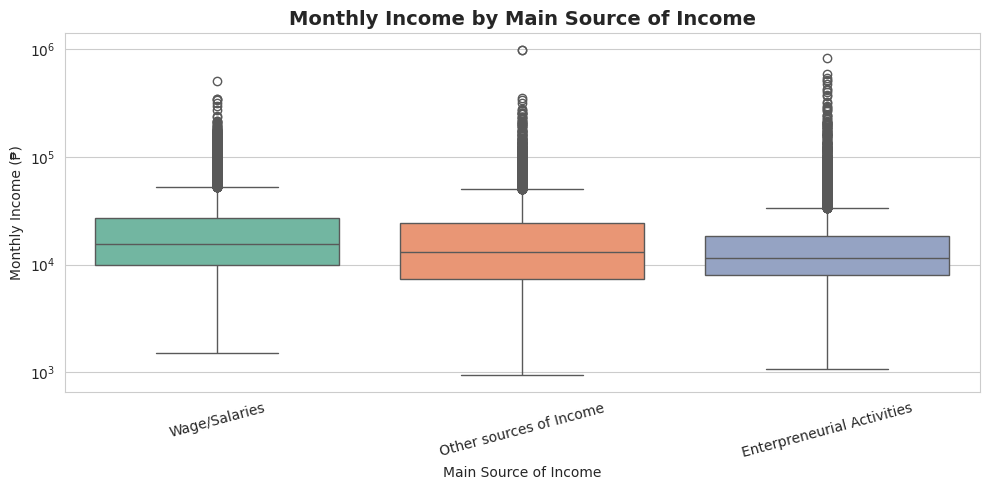


 Observation:
   Wage/Salary earners tend to have a tighter income range (more predictable).
   Entrepreneurial Activity earners have wider spread — businesses can earn a lot OR a little.
   The boxes show the middle 50% of households; the whiskers show the wider range.


In [104]:
# Income by Main Source of Income
# How does income level vary depending on HOW a household earns?

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='Main Source of Income',
    y='Monthly Income',
    palette='Set2'
)
plt.title('Monthly Income by Main Source of Income', fontsize=14, fontweight='bold')
plt.xlabel('Main Source of Income')
plt.ylabel('Monthly Income (₱)')
plt.yscale('log')  # Log scale to handle outliers
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('\n Observation:')
print('   Wage/Salary earners tend to have a tighter income range (more predictable).')
print('   Entrepreneurial Activity earners have wider spread — businesses can earn a lot OR a little.')
print('   The boxes show the middle 50% of households; the whiskers show the wider range.')

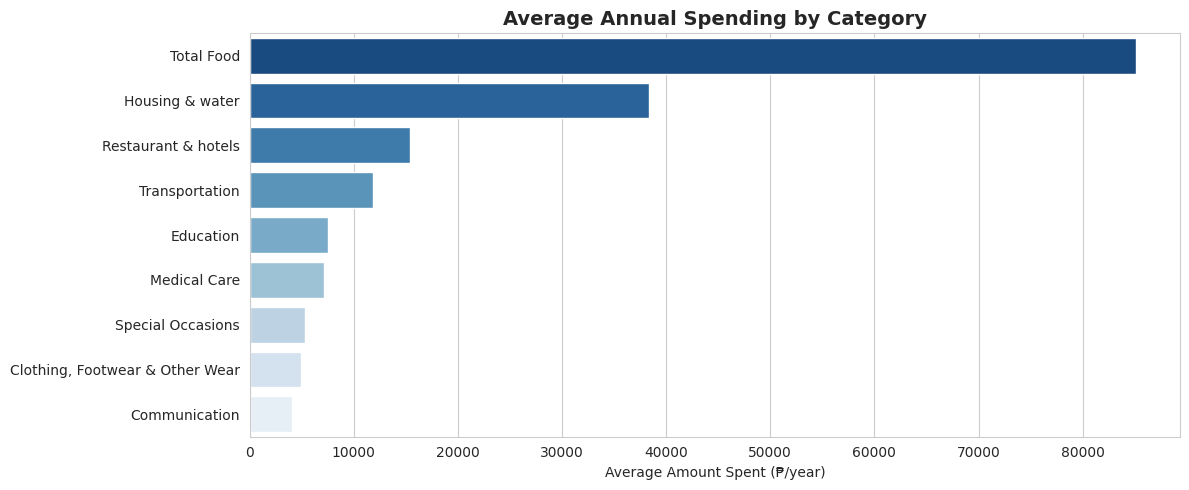


 Observation:
   Food is overwhelmingly the biggest expense — a hallmark of lower-to-middle income economies.
   Housing and Transport come next. Education spending is relatively low on average,
   though it varies widely between high- and low-income households.


In [105]:
# Top Expenditure Categories
# What do Philippine households spend most of their money on?

expenditure_cols = [
    'Total Food Expenditure', 'Housing and water Expenditure',
    'Transportation Expenditure', 'Education Expenditure',
    'Medical Care Expenditure', 'Communication Expenditure',
    'Clothing, Footwear and Other Wear Expenditure',
    'Restaurant and hotels Expenditure', 'Special Occasions Expenditure'
]

# Filter to only columns that actually exist in our dataset
expenditure_cols = [c for c in expenditure_cols if c in df.columns]

avg_spend = df[expenditure_cols].mean().sort_values(ascending=False)

# Shorten label names for display
short_labels = [c.replace(' Expenditure', '').replace(' and ', ' & ') for c in avg_spend.index]

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_spend.values, y=short_labels, palette='Blues_r')
plt.title('Average Annual Spending by Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Amount Spent (₱/year)')
plt.tight_layout()
plt.show()

print('\n Observation:')
print('   Food is overwhelmingly the biggest expense — a hallmark of lower-to-middle income economies.')
print('   Housing and Transport come next. Education spending is relatively low on average,')
print('   though it varies widely between high- and low-income households.')

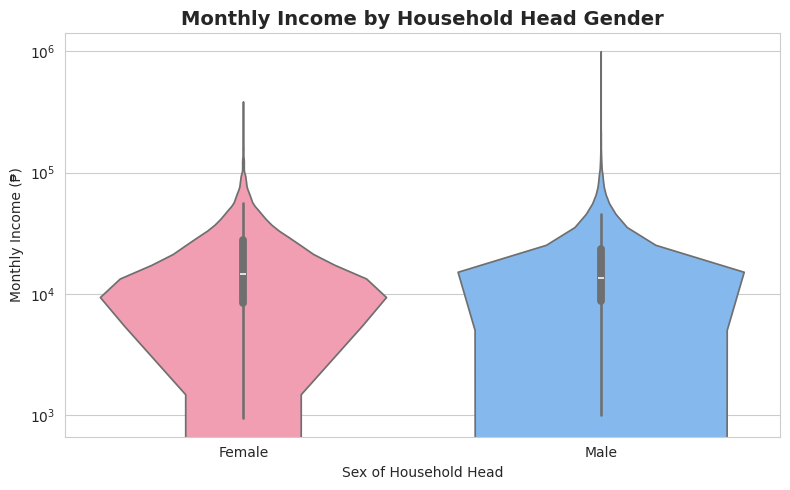


 Observation:
   The violin plot shows the full income distribution shape for each group.
   Male-headed households tend to skew slightly higher in income but both groups
   have similar lower-income concentrations.


In [106]:
# Household Head Gender vs. Income
# Is there a significant income difference based on the sex of the household head?

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df,
    x='Household Head Sex',
    y='Monthly Income',
    palette=['#FF8FAB', '#74B9FF'],
    inner='box'
)
plt.title('Monthly Income by Household Head Gender', fontsize=14, fontweight='bold')
plt.xlabel('Sex of Household Head')
plt.ylabel('Monthly Income (₱)')
plt.yscale('log')
plt.tight_layout()
plt.show()

print('\n Observation:')
print('   The violin plot shows the full income distribution shape for each group.')
print('   Male-headed households tend to skew slightly higher in income but both groups')
print('   have similar lower-income concentrations.')

## SECTION 5: Target Variable — Already Created!
Good news: **Income Brackets** was created right after loading the data (Section 2), so it's safe
no matter which cells you re-run.

The cell below just shows the class distribution so you can confirm it looks right before preprocessing.

Median Monthly Income : ₱13,673.29

Class Distribution:
  0 — Below/At Median : 20,772 households (50.0%)
  1 — Above Median    : 20,772 households (50.0%)

 Observation:
   Classes are nearly balanced (roughly 50/50 by design of using the median).
   Balanced classes are ideal for classification — no rebalancing tricks needed.




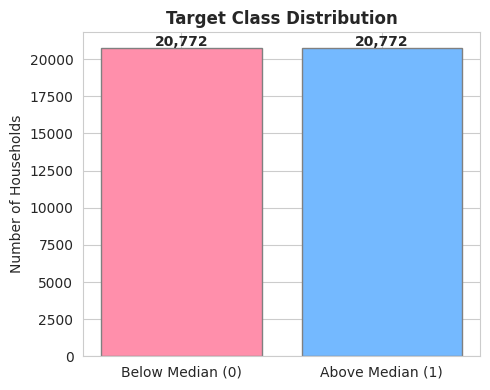

In [107]:
# Confirm the target variable looks correct
# (It was already created when we loaded the data — this cell just displays the breakdown)

class_counts = df['Income_Class'].value_counts()
print(f'Median Monthly Income : ₱{median_income:,.2f}')
print(f'\nClass Distribution:')
print(f"  0 — Below/At Median : {class_counts[0]:,} households ({class_counts[0]/len(df)*100:.1f}%)")
print(f"  1 — Above Median    : {class_counts[1]:,} households ({class_counts[1]/len(df)*100:.1f}%)")
print(f'\n Observation:')
print(f'   Classes are nearly balanced (roughly 50/50 by design of using the median).')
print(f'   Balanced classes are ideal for classification — no rebalancing tricks needed.')
print(f'\n')

# Visual check
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
plt.bar(['Below Median (0)', 'Above Median (1)'],
        [class_counts[0], class_counts[1]],
        color=['#FF8FAB', '#74B9FF'], edgecolor='gray')
plt.title('Target Class Distribution', fontweight='bold')
plt.ylabel('Number of Households')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    plt.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## SECTION 6: Data Preprocessing
Raw data is messy. Before feeding it to a model, we need to:
1. **Handle missing values** — fill gaps or drop them
2. **Encode categorical columns** — convert text labels to numbers
3. **Remove columns we don't need** — leakage prevention & noise reduction

**Important — Data Leakage:** We must remove **Monthly Income**, **Annual Household Income**, and **Total Expenditure** from our features. If we kept them, the model would be "cheating" — those columns directly determine our target, so it would get 100% accuracy without learning anything useful.

In [108]:
# --- STEP 1: Handle Missing Values ---

# For text/categorical columns: fill with the most common value (mode)
cat_cols_with_missing = df.select_dtypes(include='object').columns
for col in cat_cols_with_missing:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'  Filled "{col}" missing values with mode: "{mode_val}"')

# For numeric columns: fill with the median (less sensitive to outliers than mean)
num_cols_with_missing = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols_with_missing:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  Filled "{col}" missing values with median: {median_val}')

print(f'\n Missing values remaining: {df.isnull().sum().sum()}')

  Filled "Household Head Occupation" missing values with mode: "Farmhands and laborers"
  Filled "Household Head Class of Worker" missing values with mode: "Self-employed wihout any employee"
  Filled "Toilet Facilities" missing values with mode: "Water-sealed, sewer septic tank, used exclusively by household"

 Missing values remaining: 0


In [109]:
# --- STEP 2: Remove Leaky & Redundant Columns ---

# These columns are either:
#   (a) Direct income/expenditure totals that would 'cheat' the model (leakage), or
#   (b) Sub-components already captured in totals (redundancy)

cols_to_drop = [
    'Monthly Income',              # This IS the target — keeping it would be leakage
    'Annual Household Income',     # Directly derived from monthly income
    'Total Expenditure',           # Very strongly correlated with income
    'Total Monthly Expenditure',   # Same reason
]

# Only drop columns that actually exist
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
print(f'Remaining columns: {df.shape[1]}')

Dropped 4 columns: ['Monthly Income', 'Annual Household Income', 'Total Expenditure', 'Total Monthly Expenditure']
Remaining columns: 60


In [110]:
# --- STEP 3: Encode Categorical Columns ---

# Machine learning models only understand numbers.
# LabelEncoder converts text categories to integers:
#   e.g., 'Male' → 0,  'Female' → 1
#   e.g., 'NCR' → 5, 'CAR' → 1, etc.

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(categorical_cols)} categorical columns...')

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'  ✔ Encoded: {col}')

print(f'\n All columns are now numeric. Dataset shape: {df.shape}')

Encoding 15 categorical columns...
  ✔ Encoded: Region
  ✔ Encoded: Main Source of Income
  ✔ Encoded: Household Head Sex
  ✔ Encoded: Household Head Marital Status
  ✔ Encoded: Household Head Highest Grade Completed
  ✔ Encoded: Household Head Job or Business Indicator
  ✔ Encoded: Household Head Occupation
  ✔ Encoded: Household Head Class of Worker
  ✔ Encoded: Type of Household
  ✔ Encoded: Type of Building/House
  ✔ Encoded: Type of Roof
  ✔ Encoded: Type of Walls
  ✔ Encoded: Tenure Status
  ✔ Encoded: Toilet Facilities
  ✔ Encoded: Main Source of Water Supply

 All columns are now numeric. Dataset shape: (41544, 60)


## SECTION 7: Feature Correlation Analysis
Before training, let's see which features are most related to our target (Income_Brackets). High correlation = potentially useful predictor.

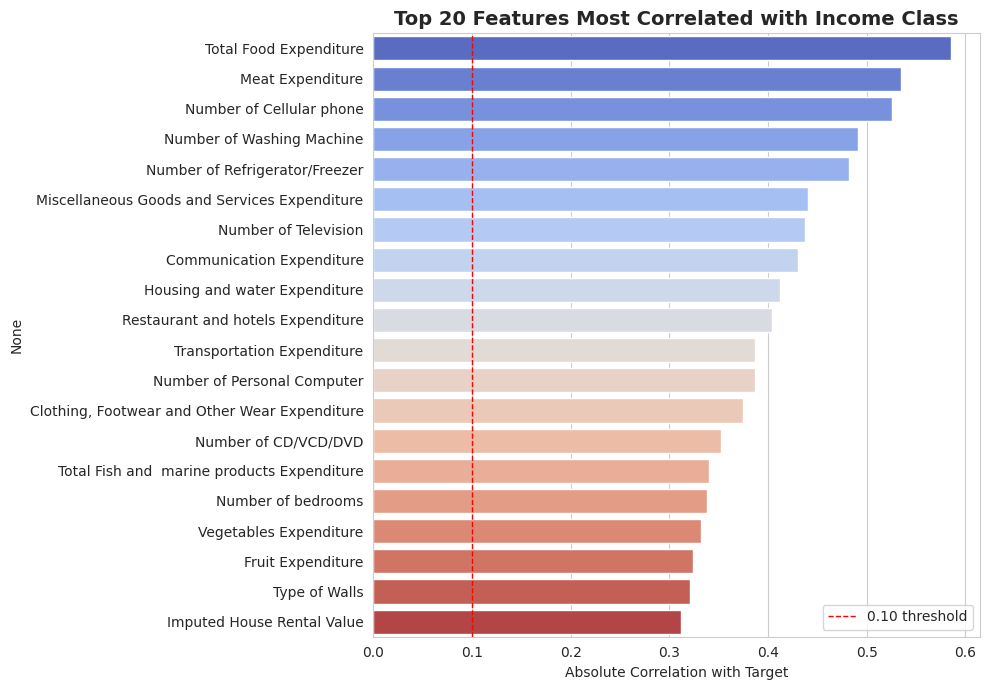


 Observation:
   Features with correlation > 0.10 are generally considered informative.
   Asset ownership (cars, aircon, computers) and expenditure categories
   tend to be strong predictors of income class — wealthier households own more.


In [111]:
# Correlation of all features WITH the target variable
corr_with_target = (
    df.corr()['Income_Class']
    .drop('Income_Class')          # Don't include the target itself
    .abs()                         # Use absolute value — negative correlation also matters
    .sort_values(ascending=False)
    .head(20)                      # Top 20 most correlated features
)

plt.figure(figsize=(10, 7))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Top 20 Features Most Correlated with Income Class', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation with Target')
plt.axvline(0.1, color='red', linestyle='--', linewidth=1, label='0.10 threshold')
plt.legend()
plt.tight_layout()
plt.show()

print('\n Observation:')
print('   Features with correlation > 0.10 are generally considered informative.')
print('   Asset ownership (cars, aircon, computers) and expenditure categories')
print('   tend to be strong predictors of income class — wealthier households own more.')

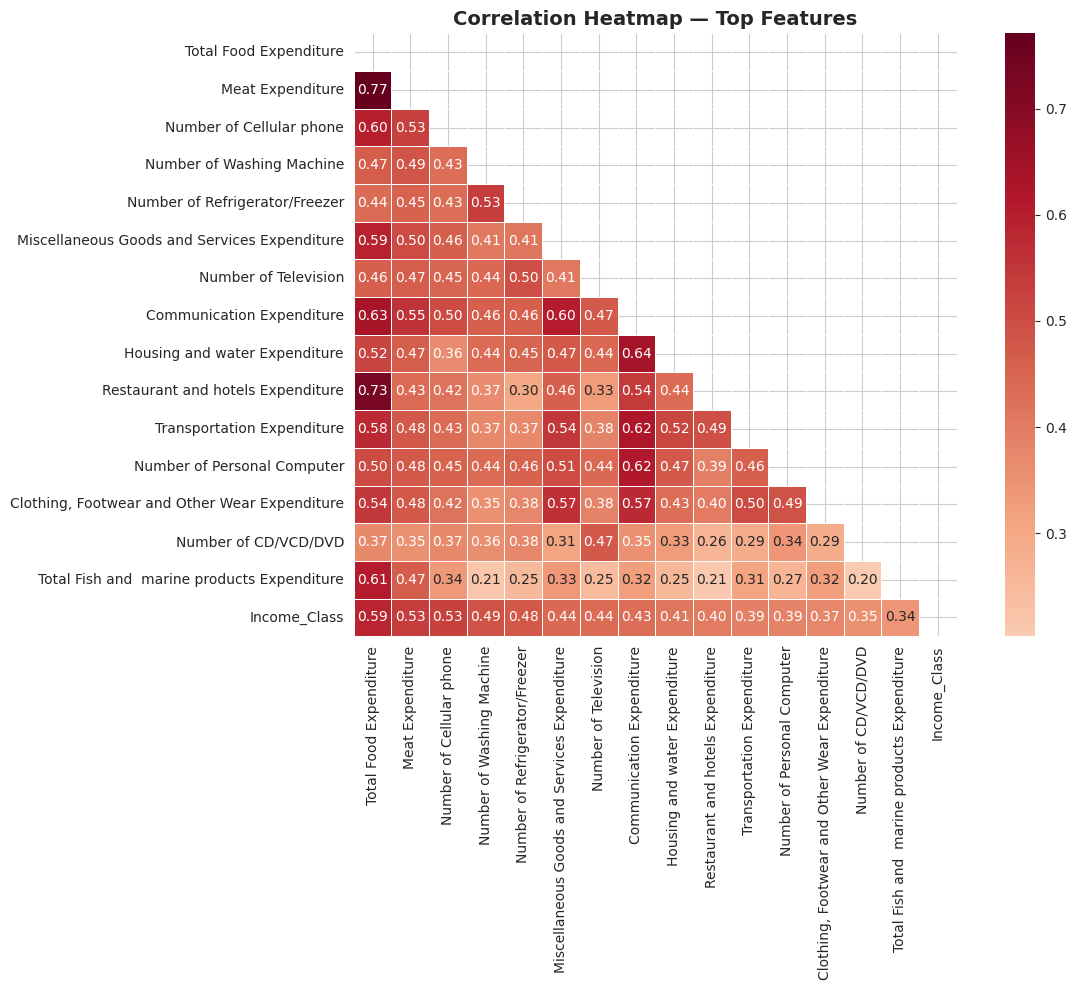


 Observation:
   Deep red = strong positive correlation, deep blue = strong negative.
   Look at the bottom row (Income_Class) to see which features align most with income.


In [112]:
# Correlation heatmap for the top 15 most correlated features
# This helps us spot if any features are highly correlated with EACH OTHER
# (called multicollinearity — can confuse simpler models)

top_features = corr_with_target.head(15).index.tolist() + ['Income_Class']

plt.figure(figsize=(13, 10))
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle (duplicates)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Observation:')
print('   Deep red = strong positive correlation, deep blue = strong negative.')
print('   Look at the bottom row (Income_Class) to see which features align most with income.')

## SECTION 8: Prepare Features & Split the Data
We separate our data into:
- **X (Features):** Everything the model uses to make predictions (inputs)
- **y (Target):** What we're trying to predict (output)

Then we split into **training set** (80%) and **test set** (20%). The model learns from the training set and is evaluated on the test set — data it has never seen before.

In [113]:
# Separate features (X) from target (y)
X = df.drop(columns=['Income_Class'])   # All columns except the target
y = df['Income_Class']                  # Just the target column

print(f'Features (X) shape : {X.shape}   ← {X.shape[1]} columns used as input')
print(f'Target   (y) shape : {y.shape}   ← 1 column to predict')
print(f'\nTarget distribution:')
print(f'  0 (Below Median): {(y == 0).sum():,}')
print(f'  1 (Above Median): {(y == 1).sum():,}')

Features (X) shape : (41544, 59)   ← 59 columns used as input
Target   (y) shape : (41544,)   ← 1 column to predict

Target distribution:
  0 (Below Median): 20,772
  1 (Above Median): 20,772


In [114]:
# Split into Training and Testing sets
# test_size=0.2 means 20% of data goes to testing
# random_state=42 ensures we get the same split every time we run (reproducibility)
# stratify=y ensures both halves have the same proportion of 0s and 1s

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set   : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set    : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\n Split complete! The model will train on {X_train.shape[0]:,} households')
print(f'   and be evaluated on {X_test.shape[0]:,} households it has never seen.')

Training set   : 33,235 rows  (80%)
Testing set    : 8,309 rows  (20%)

 Split complete! The model will train on 33,235 households
   and be evaluated on 8,309 households it has never seen.


## SECTION 9: Feature Scaling
Some features are in thousands (income) while others are single digits (number of bedrooms). This size mismatch can confuse certain models.

**StandardScaler** rescales every feature so the mean = 0 and spread = 1. This doesn't change the data's meaning — it just puts everyone on the same playing field.

**Note:** We fit the scaler only on training data, then apply it to test data. If we fit on test data too, we'd be "leaking" test information into our training process.

In [115]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on TRAINING data only, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)   # Learns the scale from training data
X_test_scaled  = scaler.transform(X_test)        # Applies the SAME scale to test data

print('Scaling complete!')
print(f'\nBefore scaling — First feature mean: {X_train.iloc[:, 0].mean():.2f}')
print(f'After  scaling — First feature mean: {X_train_scaled[:, 0].mean():.4f}   ← near 0')
print(f'After  scaling — First feature std : {X_train_scaled[:, 0].std():.4f}    ← near 1')

Scaling complete!

Before scaling — First feature mean: 8.09
After  scaling — First feature mean: -0.0000   ← near 0
After  scaling — First feature std : 1.0000    ← near 1


## SECTION 10: Model 1 — Logistic Regression
**Logistic Regression** is our baseline model. Despite the name, it's used for *classification*, not regression.

Think of it as a smart coin-flip machine: it draws a straight line through the data and says "everything on this side is class 0, everything on the other side is class 1."

**Pros:** Fast, interpretable, good baseline  
**Cons:** Assumes a linear boundary, may miss complex patterns

In [116]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

print('Logistic Regression trained!')

Logistic Regression trained!


In [117]:
# Evaluate Logistic Regression on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print('=== LOGISTIC REGRESSION RESULTS ===')
print(f'Accuracy: {lr_accuracy * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Below Median (0)', 'Above Median (1)']
))
print('\n How to read this:')
print('   Precision = Of all households the model PREDICTED as class X, how many were correct?')
print('   Recall    = Of all households that ARE class X, how many did the model find?')
print('   F1-Score  = Balance of Precision and Recall (higher = better)')

=== LOGISTIC REGRESSION RESULTS ===
Accuracy: 90.70%

Classification Report:
                  precision    recall  f1-score   support

Below Median (0)       0.90      0.92      0.91      4155
Above Median (1)       0.92      0.89      0.91      4154

        accuracy                           0.91      8309
       macro avg       0.91      0.91      0.91      8309
    weighted avg       0.91      0.91      0.91      8309


 How to read this:
   Precision = Of all households the model PREDICTED as class X, how many were correct?
   Recall    = Of all households that ARE class X, how many did the model find?
   F1-Score  = Balance of Precision and Recall (higher = better)


## SECTION 11: Model 2 — Random Forest
**Random Forest** builds hundreds of decision trees and combines their votes. Each tree asks a series of yes/no questions (e.g., "Does this household own a car?") and follows branches until it reaches a prediction.

Think of it as: instead of asking one expert, you ask 100 different experts and go with the majority vote.

**Pros:** Very accurate, handles complex patterns, works well with many features  
**Cons:** Slower to train, harder to interpret

In [118]:
# Train Random Forest
# n_estimators=100 means we build 100 trees
# random_state=42 ensures reproducibility

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)   # Random Forest doesn't need scaled data

print('Random Forest trained with 100 trees!')

Random Forest trained with 100 trees!


In [119]:
# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print('=== RANDOM FOREST RESULTS ===')
print(f'Accuracy: {rf_accuracy * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Below Median (0)', 'Above Median (1)']
))

=== RANDOM FOREST RESULTS ===
Accuracy: 90.42%

Classification Report:
                  precision    recall  f1-score   support

Below Median (0)       0.90      0.91      0.90      4155
Above Median (1)       0.91      0.90      0.90      4154

        accuracy                           0.90      8309
       macro avg       0.90      0.90      0.90      8309
    weighted avg       0.90      0.90      0.90      8309



## SECTION 12: Model Comparison
Now let's compare both models side by side and visualize their confusion matrices.

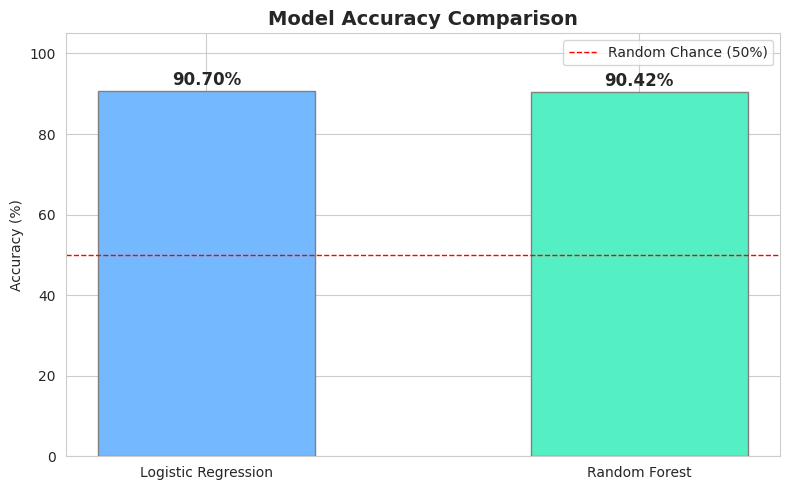


 Best performing model: Logistic Regression (90.70%)


In [120]:
# Side-by-side accuracy comparison
models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_accuracy * 100, rf_accuracy * 100]

colors = ['#74B9FF', '#55EFC4']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='gray', width=0.5)
plt.ylim(0, 105)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Random Chance (50%)')
plt.legend()

# Add accuracy labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

winner = models[accuracies.index(max(accuracies))]
print(f'\n Best performing model: {winner} ({max(accuracies):.2f}%)')

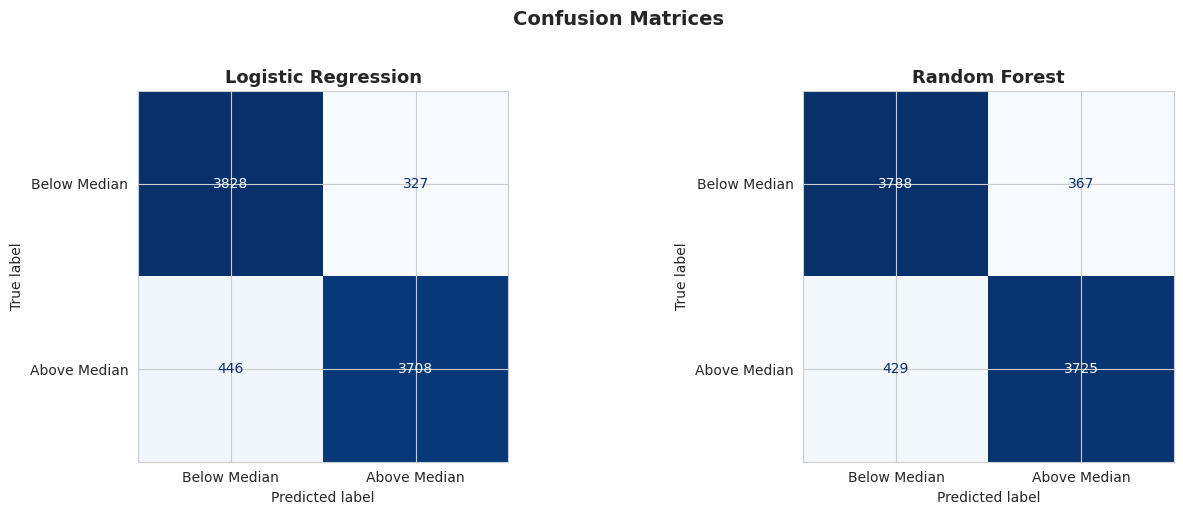


 How to read the Confusion Matrix:
   TOP-LEFT    = Correctly predicted Below Median (True Negative)
   TOP-RIGHT   = Predicted Above Median, but was actually Below Median (False Positive)
   BOTTOM-LEFT = Predicted Below Median, but was actually Above Median (False Negative)
   BOTTOM-RIGHT= Correctly predicted Above Median (True Positive)
   → Ideally, the diagonal (top-left to bottom-right) should have the most counts.


In [121]:
# Confusion Matrices — side by side
# A confusion matrix shows: True Positives, True Negatives, False Positives, False Negatives
# It tells us WHERE the model is making mistakes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, preds, name in zip(
    axes,
    [lr_model, rf_model],
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Below Median', 'Above Median']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n How to read the Confusion Matrix:')
print('   TOP-LEFT    = Correctly predicted Below Median (True Negative)')
print('   TOP-RIGHT   = Predicted Above Median, but was actually Below Median (False Positive)')
print('   BOTTOM-LEFT = Predicted Below Median, but was actually Above Median (False Negative)')
print('   BOTTOM-RIGHT= Correctly predicted Above Median (True Positive)')
print('   → Ideally, the diagonal (top-left to bottom-right) should have the most counts.')

## SECTION 13: Feature Importance
One of the most valuable outputs of a Random Forest is **feature importance** — which inputs had the most influence on predictions. This helps us understand WHAT actually drives income class.

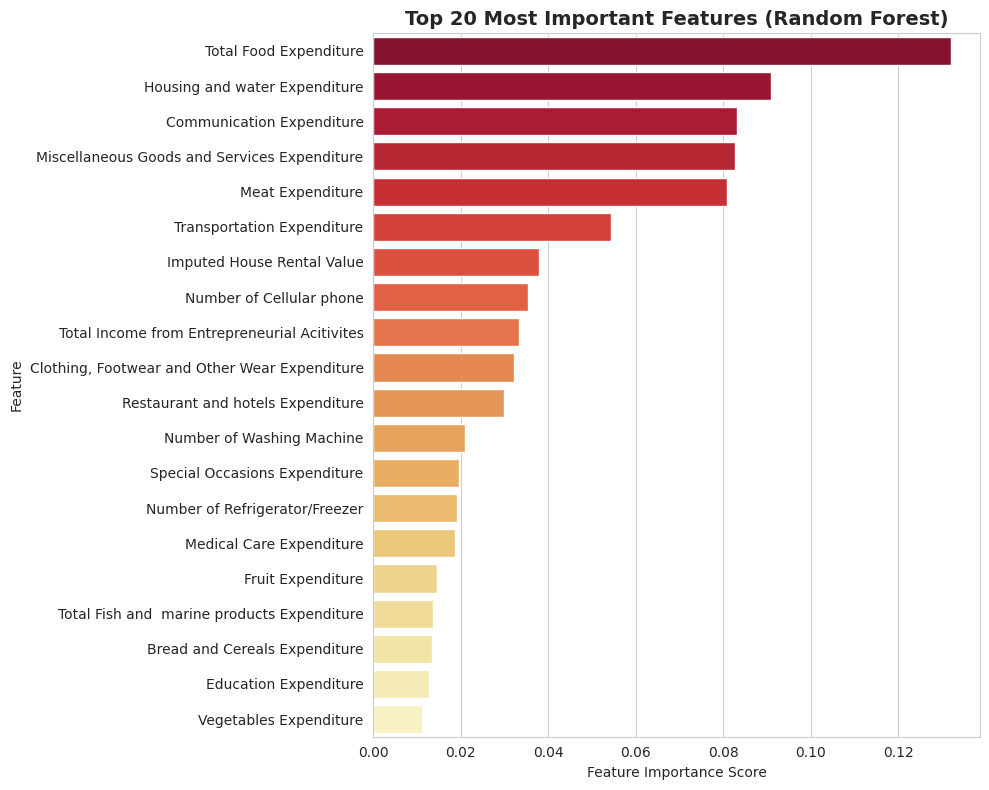


 Observation:
   The most important features are the ones the Random Forest relied on most when
   splitting its decision trees to classify households.
   Expenditure categories often dominate — spending habits are strong income proxies.
   Household assets (TV, car, aircon) also tend to rank high.


In [122]:
# Extract feature importances from Random Forest
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature',
    palette='YlOrRd_r'
)
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\n Observation:')
print('   The most important features are the ones the Random Forest relied on most when')
print('   splitting its decision trees to classify households.')
print('   Expenditure categories often dominate — spending habits are strong income proxies.')
print('   Household assets (TV, car, aircon) also tend to rank high.')

## SECTION 14: Summary & Key Takeaways

In [123]:
# Print final summary
print('=' * 55)
print('  PHILIPPINE HOUSEHOLD INCOME CLASSIFICATION SUMMARY')
print('=' * 55)
print(f'  Dataset         : FIES — {len(df):,} households')
print(f'  Features used   : {X.shape[1]} columns')
print(f'  Target variable : Income_Class (above/below median)')
print(f'  Median income   : ₱{median_income:,.2f}/month')
print()
print(f'  Model Results:')
print(f'    Logistic Regression : {lr_accuracy*100:.2f}%')
print(f'    Random Forest       : {rf_accuracy*100:.2f}%')
print(f'    Winner              : {winner}')
print()
print('  Key Findings:')
print('  • Spending on food, housing, and transport are the')
print('    strongest predictors of income class')
print('  • Asset ownership (cars, aircon, computers) strongly')
print('    separates above- from below-median households')
print('  • NCR and CALABARZON have the highest median incomes')
print('  • Wage/salary earners dominate but have tighter income spread')
print('  • Both models perform significantly better than random chance')
print('=' * 55)

  PHILIPPINE HOUSEHOLD INCOME CLASSIFICATION SUMMARY
  Dataset         : FIES — 41,544 households
  Features used   : 59 columns
  Target variable : Income_Class (above/below median)
  Median income   : ₱13,673.29/month

  Model Results:
    Logistic Regression : 90.70%
    Random Forest       : 90.42%
    Winner              : Logistic Regression

  Key Findings:
  • Spending on food, housing, and transport are the
    strongest predictors of income class
  • Asset ownership (cars, aircon, computers) strongly
    separates above- from below-median households
  • NCR and CALABARZON have the highest median incomes
  • Wage/salary earners dominate but have tighter income spread
  • Both models perform significantly better than random chance


---
## SECTION 15: Model 3 — Decision Tree Classifier

A single tree that learns a chain of yes/no rules from the data. Each split asks one question about a feature (e.g. *"Is food expenditure > ₱80,000?"*) and follows a branch until it reaches a prediction.

**Pros:** Easy to visualize and explain to non-technical people  
**Cons:** Tends to overfit — it can memorize training data if the tree grows too deep. `max_depth=10` limits how many questions it can ask, which keeps it more general.

In [124]:
# Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)   # Tree models don't need scaled data

print('Decision Tree trained! (max_depth=10)')


Decision Tree trained! (max_depth=10)


=== DECISION TREE CLASSIFIER RESULTS ===
Accuracy: 88.54%

Classification Report:
                  precision    recall  f1-score   support

Below Median (0)       0.87      0.91      0.89      4155
Above Median (1)       0.91      0.86      0.88      4154

        accuracy                           0.89      8309
       macro avg       0.89      0.89      0.89      8309
    weighted avg       0.89      0.89      0.89      8309

Confusion Matrix:


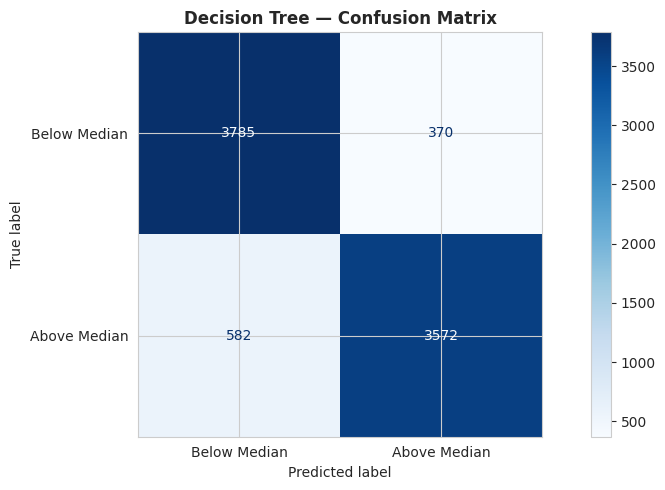

In [125]:
# Evaluate Decision Tree
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print('=== DECISION TREE CLASSIFIER RESULTS ===')
print(f'Accuracy: {dt_accuracy * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(
    y_test, y_pred_dt,
    target_names=['Below Median (0)', 'Above Median (1)']
))
print('Confusion Matrix:')
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                  display_labels=['Below Median', 'Above Median'])
disp_dt.plot(cmap='Blues')
plt.title('Decision Tree — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


---
## SECTION 16: Model 4 — K-Nearest Neighbors (KNN) Classifier

KNN doesn't build a model in the traditional sense — it memorizes the entire training set. When predicting a new household, it finds the **k most similar households** in training data and takes a majority vote among them.

Think of it as: *"This household looks like 15 others I've seen. 11 of those were above-median — so I'll predict above-median."*

**Important:** KNN uses distance calculations between data points, so it **requires scaled data** — otherwise features with large values (like income in thousands) would dominate over features with small values (like number of bedrooms).

In [126]:
# Train K-Nearest Neighbors Classifier
# n_neighbors=15: looks at 15 closest households to make a decision
# Larger k = smoother predictions, less sensitive to noise
knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)   # KNN requires scaled data

print('K-Nearest Neighbors trained! (k=15)')


K-Nearest Neighbors trained! (k=15)


=== K-NEAREST NEIGHBORS CLASSIFIER RESULTS ===
Accuracy: 84.28%  (k=15 neighbors)

Classification Report:
                  precision    recall  f1-score   support

Below Median (0)       0.78      0.95      0.86      4155
Above Median (1)       0.93      0.74      0.82      4154

        accuracy                           0.84      8309
       macro avg       0.86      0.84      0.84      8309
    weighted avg       0.86      0.84      0.84      8309

Confusion Matrix:


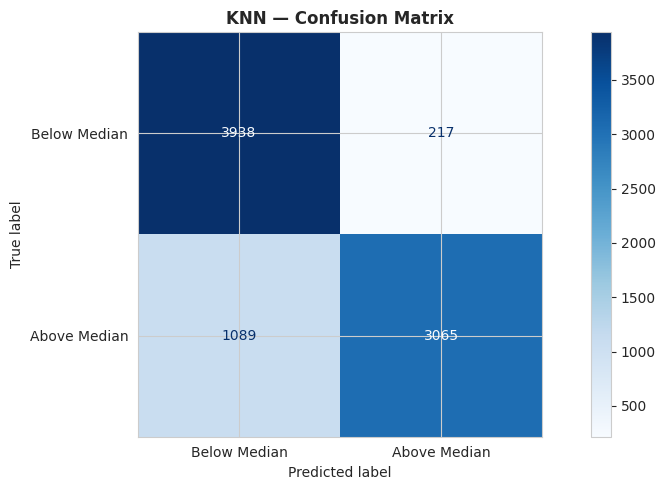

In [127]:
# Evaluate KNN
y_pred_knn = knn_model.predict(X_test_scaled)   # Must use scaled test data
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print('=== K-NEAREST NEIGHBORS CLASSIFIER RESULTS ===')
print(f'Accuracy: {knn_accuracy * 100:.2f}%  (k=15 neighbors)')
print()
print('Classification Report:')
print(classification_report(
    y_test, y_pred_knn,
    target_names=['Below Median (0)', 'Above Median (1)']
))
print('Confusion Matrix:')
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                                   display_labels=['Below Median', 'Above Median'])
disp_knn.plot(cmap='Blues')
plt.title('KNN — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


---
## SECTION 17: Model 5 — Gradient Boosting Classifier

Gradient Boosting builds trees **one after another in sequence**. Each new tree focuses specifically on fixing the mistakes the previous trees made — like a team where every new member covers what the last person got wrong.

This is the core idea behind powerful libraries like **XGBoost** and **LightGBM** that dominate data science competitions.

- **n_estimators=100** — builds 100 sequential trees  
- **learning_rate=0.1** — how much each tree corrects the previous (lower = more careful, needs more trees)  
- **max_depth=4** — limits each individual tree's complexity

**Note:** Gradient Boosting is slower to train than Random Forest because trees are built one by one, not in parallel.

In [128]:
# Train Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb_model.fit(X_train, y_train)

print('Gradient Boosting trained! (100 sequential trees)')


Gradient Boosting trained! (100 sequential trees)


=== GRADIENT BOOSTING CLASSIFIER RESULTS ===
Accuracy: 91.42%

Classification Report:
                  precision    recall  f1-score   support

Below Median (0)       0.91      0.92      0.91      4155
Above Median (1)       0.92      0.91      0.91      4154

        accuracy                           0.91      8309
       macro avg       0.91      0.91      0.91      8309
    weighted avg       0.91      0.91      0.91      8309

Confusion Matrix:


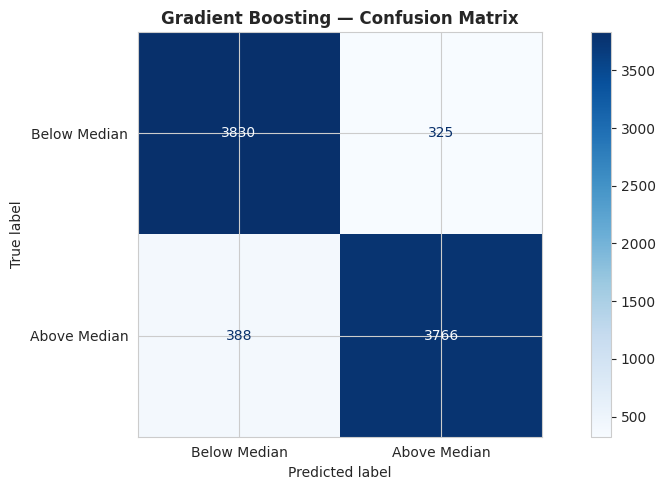

In [129]:
# Evaluate Gradient Boosting
y_pred_gb = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print('=== GRADIENT BOOSTING CLASSIFIER RESULTS ===')
print(f'Accuracy: {gb_accuracy * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(
    y_test, y_pred_gb,
    target_names=['Below Median (0)', 'Above Median (1)']
))
print('Confusion Matrix:')
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb,
                                  display_labels=['Below Median', 'Above Median'])
disp_gb.plot(cmap='Blues')
plt.title('Gradient Boosting — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


## SECTION 18: Classification Leaderboard — All 5 Models

Now we compare all five classifiers in one view. This replaces the 2-model comparison from Section 12 with the full picture.

=== CLASSIFICATION LEADERBOARD — ALL 5 MODELS ===
 Rank               Model  Accuracy (%)
    1   Gradient Boosting         91.42
    2 Logistic Regression         90.70
    3       Random Forest         90.42
    4       Decision Tree         88.54
    5 K-Nearest Neighbors         84.28



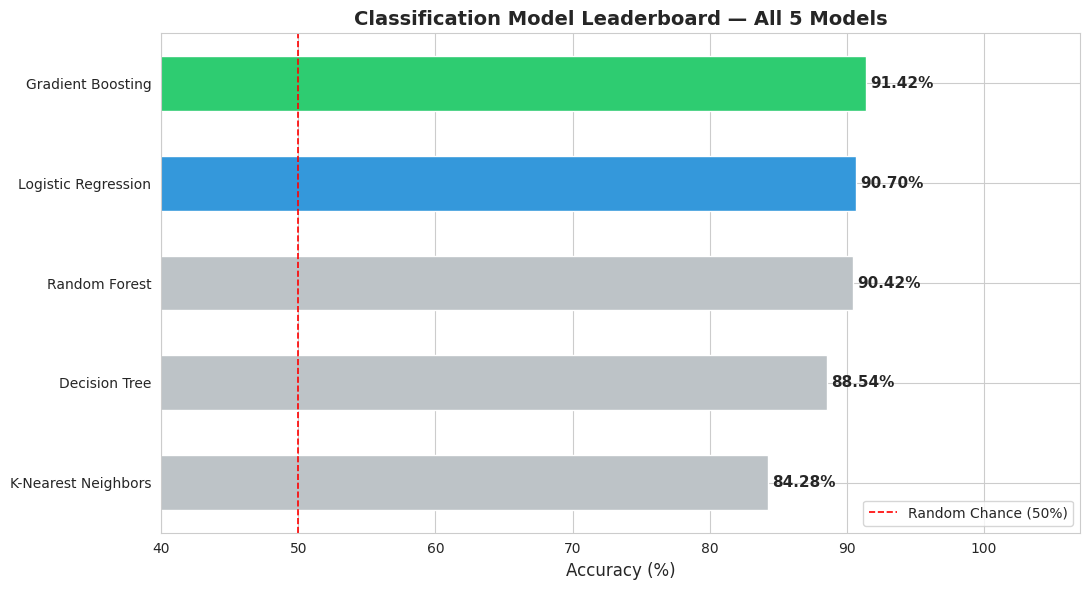

Best Classifier : Gradient Boosting — 91.42%
Worst Classifier: K-Nearest Neighbors — 84.28%


In [130]:
# Build the full classification leaderboard
clf_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Decision Tree',
        'K-Nearest Neighbors',
        'Gradient Boosting'
    ],
    'Accuracy (%)': [
        lr_accuracy * 100,
        rf_accuracy * 100,
        dt_accuracy * 100,
        knn_accuracy * 100,
        gb_accuracy * 100
    ]
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

clf_results['Rank'] = clf_results.index + 1
clf_results['Accuracy (%)'] = clf_results['Accuracy (%)'].round(2)

print('=== CLASSIFICATION LEADERBOARD — ALL 5 MODELS ===')
print(clf_results[['Rank', 'Model', 'Accuracy (%)']].to_string(index=False))
print()

# Sort ASCENDING for the chart so highest bar appears at the top
clf_chart = clf_results.sort_values('Accuracy (%)', ascending=True).reset_index(drop=True)

# Color: green = best (last row after ascending sort), blue = 2nd best, gray = rest
palette = []
for i in range(len(clf_chart)):
    if i == len(clf_chart) - 1:
        palette.append('#2ecc71')   # green  → rank 1 (top bar)
    elif i == len(clf_chart) - 2:
        palette.append('#3498db')   # blue   → rank 2
    else:
        palette.append('#bdc3c7')   # gray   → rest

plt.figure(figsize=(11, 6))
bars = plt.barh(
    clf_chart['Model'],
    clf_chart['Accuracy (%)'],
    color=palette, edgecolor='white', height=0.55
)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.title('Classification Model Leaderboard — All 5 Models', fontsize=14, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.2, label='Random Chance (50%)')
plt.xlim(40, 107)
plt.legend()

# Annotate each bar with its own accuracy — no reversal needed
for bar, acc in zip(bars, clf_chart['Accuracy (%)']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{acc:.2f}%', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

best_clf = clf_results.iloc[0]
print(f'Best Classifier : {best_clf["Model"]} — {best_clf["Accuracy (%)"]:.2f}%')
print(f'Worst Classifier: {clf_results.iloc[-1]["Model"]} — {clf_results.iloc[-1]["Accuracy (%)"]:.2f}%')

## SECTION 19: Regression Setup

We now switch from **classification** to **regression**.

| | Classification | Regression |
|---|---|---|
| **Question** | Which income class? | How much income exactly? |
| **Output** | `0` or `1` | e.g. `₱18,450.75` |
| **Metrics** | Accuracy, F1, Precision, Recall | MAE, MAPE, RMSE, R² |

**New metrics explained:**

| Metric | Full Name | What it tells you |
|---|---|---|
| **MAE** | Mean Absolute Error | Average peso distance between predicted and actual income |
| **MAPE** | Mean Absolute Percentage Error | Same error, expressed as a % of the actual income |
| **RMSE** | Root Mean Squared Error | Like MAE but penalizes large errors more heavily |
| **R²** | R-squared | How much of income variation the model explains (1.0 = perfect) |

**Note on MAPE:** MAPE is undefined when the actual income value is zero (division by zero). Since no household has zero income in this dataset, we can safely compute it for all rows.

In [131]:
# --- REGRESSION SETUP ---

# Re-load monthly income from the CSV (it was dropped during classification preprocessing)
df_raw = pd.read_csv('/content/drive/MyDrive/Uplift - Python for Data and AI/0413 Model Training Activity (Basic Machine Learning)/Family Income and Expenditure_edited.csv')
y_reg = df_raw['Monthly Income']   # Continuous peso target

# Features: reuse X (same preprocessed columns, no income leakage)
X_reg = X.copy()

# Train/test split — same random_state=42 for consistency
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale for linear models
scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs  = scaler_r.transform(X_test_r)

# Helper function — prints MAE, MAPE, RMSE, R² cleanly
def reg_report(model_name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'=== {model_name} ===')
    print(f'  MAE  : ₱{mae:>12,.2f}   ← average peso error per household')
    print(f'  MAPE :  {mape:>11.2f}%   ← average % error relative to actual income')
    print(f'  RMSE : ₱{rmse:>12,.2f}   ← penalizes large prediction errors more')
    print(f'  R²   :  {r2:>11.4f}    ← 1.0 = perfect | 0.0 = no better than guessing mean')
    print()
    return {'Model': model_name, 'MAE (₱)': round(mae, 2),
            'MAPE (%)': round(mape, 2), 'RMSE (₱)': round(rmse, 2), 'R²': round(r2, 4)}

reg_results = []   # Collect all results here for comparison

print(f'  Regression setup complete!')
print(f'  Training rows : {X_train_r.shape[0]:,}')
print(f'  Testing rows  : {X_test_r.shape[0]:,}')
print(f'  Income range  : ₱{y_reg.min():,.0f} — ₱{y_reg.max():,.0f}/month')
print(f'  Median income : ₱{y_reg.median():,.2f}/month')


  Regression setup complete!
  Training rows : 33,235
  Testing rows  : 8,309
  Income range  : ₱940 — ₱984,666/month
  Median income : ₱13,673.29/month


## SECTION 20: Regressor 1 — Linear Regression

The simplest regression model. It finds the best-fit straight line through the data by assigning a **weight (coefficient)** to each feature.

For example: *"Each additional car owned adds ₱X to the predicted income. Each extra family member subtracts ₱Y."*

**Pros:** Very fast, highly interpretable, good baseline  
**Cons:** Can only capture straight-line (linear) relationships — misses curves and interactions

In [132]:
# Train Linear Regression
linreg_model = LinearRegression()
linreg_model.fit(X_train_rs, y_train_r)   # Linear models need scaled data

y_pred_linreg = linreg_model.predict(X_test_rs)

result = reg_report('Linear Regression', y_test_r, y_pred_linreg)
reg_results.append(result)

print('   Observation:')
print('   MAE tells you the average peso gap between what the model predicted')
print('   and what the household actually earns.')
print('   MAPE shows that same error as a percentage — useful for comparing')
print('   across households with very different income levels.')


=== Linear Regression ===
  MAE  : ₱    4,213.75   ← average peso error per household
  MAPE :        23.18%   ← average % error relative to actual income
  RMSE : ₱    7,918.51   ← penalizes large prediction errors more
  R²   :       0.8754    ← 1.0 = perfect | 0.0 = no better than guessing mean

   Observation:
   MAE tells you the average peso gap between what the model predicted
   and what the household actually earns.
   MAPE shows that same error as a percentage — useful for comparing
   across households with very different income levels.


---
## SECTION 21: Regressor 2 — Ridge Regression

Ridge is Linear Regression with a **regularization penalty**. It adds a small punishment for assigning very large weights to any single feature. This prevents the model from over-relying on one predictor and makes it more stable.

Think of it as: *"You can use all features, but no single feature is allowed to dominate."*

This is especially useful here because many of our features (food expenditure, rice expenditure, meat expenditure) are correlated with each other — a phenomenon called **multicollinearity** that can confuse plain Linear Regression.

**alpha=1.0** controls how strong the penalty is. Higher alpha = more regularization.

In [133]:
# Train Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_rs, y_train_r)

y_pred_ridge = ridge_model.predict(X_test_rs)

result = reg_report('Ridge Regression', y_test_r, y_pred_ridge)
reg_results.append(result)

print('   Observation:')
print('   Compare Ridge MAE/MAPE to Linear Regression above.')
print('   If Ridge is better, it means multicollinearity was hurting Linear Regression.')
print('   If they are similar, the penalty did not change much in this dataset.')


=== Ridge Regression ===
  MAE  : ₱    4,213.71   ← average peso error per household
  MAPE :        23.18%   ← average % error relative to actual income
  RMSE : ₱    7,918.48   ← penalizes large prediction errors more
  R²   :       0.8754    ← 1.0 = perfect | 0.0 = no better than guessing mean

   Observation:
   Compare Ridge MAE/MAPE to Linear Regression above.
   If Ridge is better, it means multicollinearity was hurting Linear Regression.
   If they are similar, the penalty did not change much in this dataset.


---
## SECTION 22: Regressor 3 — Random Forest Regressor

Same idea as the Random Forest Classifier in Section 11 — builds 100 decision trees and combines their outputs. But instead of voting for a class, each tree **predicts a peso amount**, and the final prediction is the **average** of all 100 trees.

Averaging smooths out extreme individual predictions that a single tree might make. This is called **ensemble learning**.

This is the **regressor version** (RandomForestRegressor) — the classifier version (RandomForestClassifier) is what you used in Section 11.

In [134]:
# Train Random Forest Regressor
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_model.fit(X_train_r, y_train_r)   # Tree models don't need scaled data

y_pred_rf_reg = rf_reg_model.predict(X_test_r)

result = reg_report('Random Forest Regressor', y_test_r, y_pred_rf_reg)
reg_results.append(result)

print('   Observation:')
print('   Random Forest Regressor usually produces a strong R² on this type of data.')
print('   A high R² (e.g. 0.75+) means the model explains most of the income variation')
print('   using household characteristics alone — without seeing the actual income.')


=== Random Forest Regressor ===
  MAE  : ₱    3,991.33   ← average peso error per household
  MAPE :        19.64%   ← average % error relative to actual income
  RMSE : ₱    7,918.27   ← penalizes large prediction errors more
  R²   :       0.8754    ← 1.0 = perfect | 0.0 = no better than guessing mean

   Observation:
   Random Forest Regressor usually produces a strong R² on this type of data.
   A high R² (e.g. 0.75+) means the model explains most of the income variation
   using household characteristics alone — without seeing the actual income.


## SECTION 23: Regressor 4 — Gradient Boosting Regressor

The regression version of the Gradient Boosting Classifier from Section 17. Each tree corrects the **prediction error (residual)** of the previous tree — building a highly accurate model step by step.

Every new tree essentially asks: *"Where was the previous model most wrong, and how do I fix that?"*

This approach often competes with Random Forest for the top spot on tabular datasets.

In [135]:
# Train Gradient Boosting Regressor
gb_reg_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb_reg_model.fit(X_train_r, y_train_r)

y_pred_gb_reg = gb_reg_model.predict(X_test_r)

result = reg_report('Gradient Boosting Regressor', y_test_r, y_pred_gb_reg)
reg_results.append(result)

print('   Observation:')
print('   Gradient Boosting is often the top performer on regression tasks.')
print('   Compare its MAPE and R² against Random Forest Regressor above')
print('   to see which approach better captures income patterns in this dataset.')


=== Gradient Boosting Regressor ===
  MAE  : ₱    3,928.99   ← average peso error per household
  MAPE :        20.42%   ← average % error relative to actual income
  RMSE : ₱    7,799.08   ← penalizes large prediction errors more
  R²   :       0.8791    ← 1.0 = perfect | 0.0 = no better than guessing mean

   Observation:
   Gradient Boosting is often the top performer on regression tasks.
   Compare its MAPE and R² against Random Forest Regressor above
   to see which approach better captures income patterns in this dataset.


## SECTION 24: Regressor 5 — Decision Tree Regressor

A single decision tree that predicts income. Instead of a class label at the end of each branch, it outputs the **average income of all training households** that fell into that leaf.

Example rule: *"If food expenditure > ₱80K AND owns a car → average income = ₱45,000"*

**Useful as a baseline** for tree-based regression. Its weakness is that a single tree is prone to overfitting — which is exactly why Random Forest and Gradient Boosting (ensembles of many trees) tend to outperform it.

In [136]:
# Train Decision Tree Regressor
dt_reg_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_reg_model.fit(X_train_r, y_train_r)

y_pred_dt_reg = dt_reg_model.predict(X_test_r)

result = reg_report('Decision Tree Regressor', y_test_r, y_pred_dt_reg)
reg_results.append(result)

print('   Observation:')
print('   Decision Tree Regressor typically shows higher MAE and MAPE than the ensemble')
print('   models (Random Forest, Gradient Boosting) because it uses only one tree.')
print('   If it scores similarly to them, the income patterns in this data are very')
print('   rule-like and can be captured by simple splits.')


=== Decision Tree Regressor ===
  MAE  : ₱    4,926.83   ← average peso error per household
  MAPE :        24.82%   ← average % error relative to actual income
  RMSE : ₱    9,808.00   ← penalizes large prediction errors more
  R²   :       0.8089    ← 1.0 = perfect | 0.0 = no better than guessing mean

   Observation:
   Decision Tree Regressor typically shows higher MAE and MAPE than the ensemble
   models (Random Forest, Gradient Boosting) because it uses only one tree.
   If it scores similarly to them, the income patterns in this data are very
   rule-like and can be captured by simple splits.


## SECTION 25: Regression Leaderboard — All 5 Models

Comparing all five regressors across all four metrics. Remember: for MAE and MAPE and RMSE, **lower is better**. For R², **higher is better**.

=== REGRESSION LEADERBOARD (sorted by R²) ===
 Rank                       Model  MAE (₱)  MAPE (%)  RMSE (₱)     R²
    1 Gradient Boosting Regressor  3928.99     20.42   7799.08 0.8791
    2           Linear Regression  4213.75     23.18   7918.51 0.8754
    3            Ridge Regression  4213.71     23.18   7918.48 0.8754
    4     Random Forest Regressor  3991.33     19.64   7918.27 0.8754
    5     Decision Tree Regressor  4926.83     24.82   9808.00 0.8089



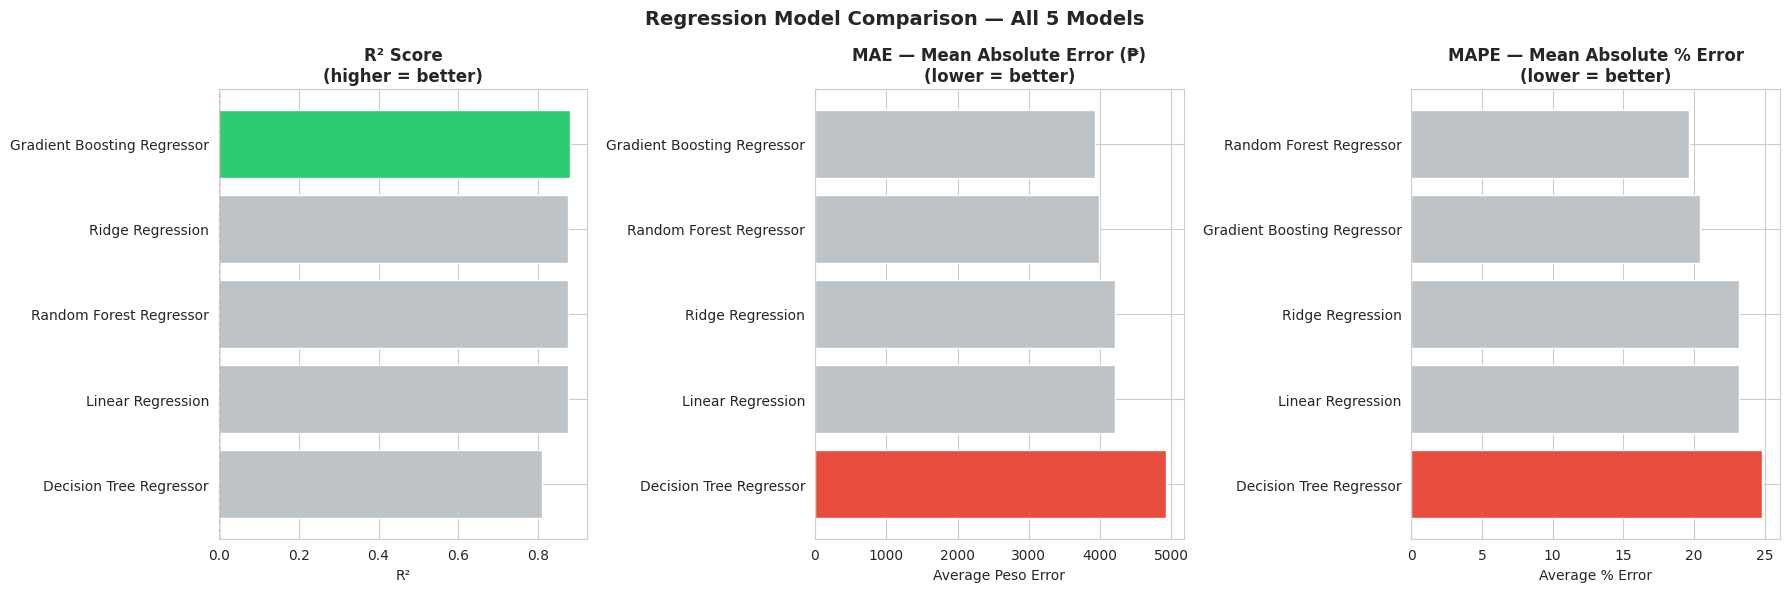

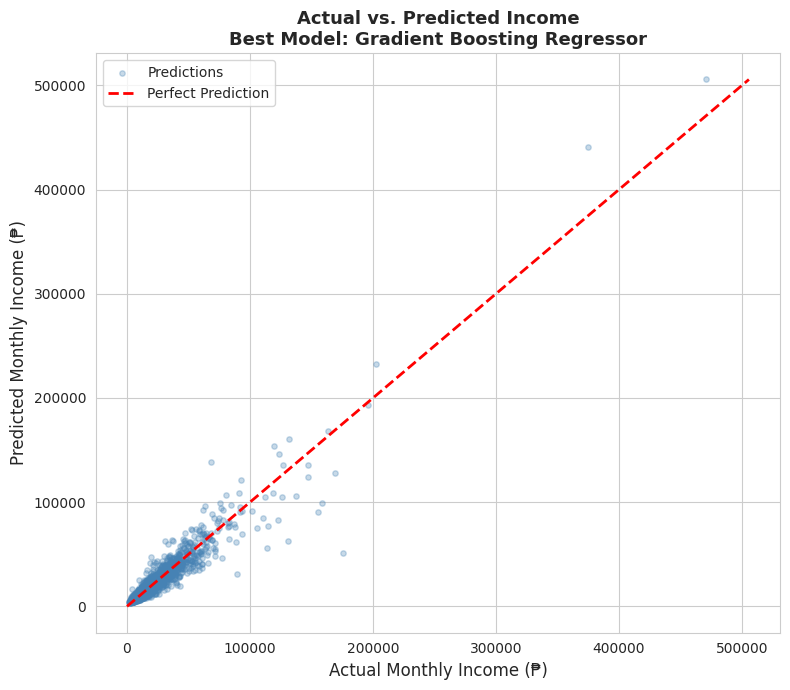

/n Best Regressor : Gradient Boosting Regressor
  R²      : 0.8791
  MAE     : ₱3928.99
  MAPE    : 20.42%
  RMSE    : ₱7799.08

How to read the Actual vs. Predicted chart:
  Dots on the red line = perfect predictions.
  Dots above the line = model over-predicted income.
  Dots below the line = model under-predicted income.
  High-income households (right side) are harder to predict — fewer training examples.


In [137]:
# Build regression leaderboard (sorted by R²)
reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False).reset_index(drop=True)
reg_df['Rank'] = reg_df.index + 1

print('=== REGRESSION LEADERBOARD (sorted by R²) ===')
print(reg_df[['Rank', 'Model', 'MAE (₱)', 'MAPE (%)', 'RMSE (₱)', 'R²']].to_string(index=False))
print()

# --- Chart 1: R² comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

reg_sorted_r2   = pd.DataFrame(reg_results).sort_values('R²', ascending=True)
reg_sorted_mae  = pd.DataFrame(reg_results).sort_values('MAE (₱)', ascending=False)
reg_sorted_mape = pd.DataFrame(reg_results).sort_values('MAPE (%)', ascending=False)

palette_r2   = ['#2ecc71' if i == len(reg_sorted_r2)-1 else '#bdc3c7' for i in range(len(reg_sorted_r2))]
palette_mae  = ['#e74c3c' if i == 0 else '#bdc3c7' for i in range(len(reg_sorted_mae))]
palette_mape = ['#e74c3c' if i == 0 else '#bdc3c7' for i in range(len(reg_sorted_mape))]

axes[0].barh(reg_sorted_r2['Model'], reg_sorted_r2['R²'], color=palette_r2)
axes[0].set_title('R² Score\n(higher = better)', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)

axes[1].barh(reg_sorted_mae['Model'], reg_sorted_mae['MAE (₱)'], color=palette_mae)
axes[1].set_title('MAE — Mean Absolute Error (₱)\n(lower = better)', fontweight='bold')
axes[1].set_xlabel('Average Peso Error')

axes[2].barh(reg_sorted_mape['Model'], reg_sorted_mape['MAPE (%)'], color=palette_mape)
axes[2].set_title('MAPE — Mean Absolute % Error\n(lower = better)', fontweight='bold')
axes[2].set_xlabel('Average % Error')

plt.suptitle('Regression Model Comparison — All 5 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Chart 2: Predicted vs. Actual for best model ---
best_reg_name = reg_df.iloc[0]['Model']
pred_map = {
    'Linear Regression'           : y_pred_linreg,
    'Ridge Regression'            : y_pred_ridge,
    'Random Forest Regressor'     : y_pred_rf_reg,
    'Gradient Boosting Regressor' : y_pred_gb_reg,
    'Decision Tree Regressor'     : y_pred_dt_reg,
}
best_preds = pred_map[best_reg_name]

# Sample 2,000 points so the chart stays readable
sample_idx = np.random.RandomState(42).choice(len(y_test_r), 2000, replace=False)
y_actual_s = np.array(y_test_r)[sample_idx]
y_pred_s   = best_preds[sample_idx]

plt.figure(figsize=(8, 7))
plt.scatter(y_actual_s, y_pred_s, alpha=0.3, s=15, color='steelblue', label='Predictions')
max_val = max(y_actual_s.max(), y_pred_s.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Monthly Income (₱)', fontsize=12)
plt.ylabel('Predicted Monthly Income (₱)', fontsize=12)
plt.title(f'Actual vs. Predicted Income\nBest Model: {best_reg_name}',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'/n Best Regressor : {reg_df.iloc[0]["Model"]}')
print(f'  R²      : {reg_df.iloc[0]["R²"]}')
print(f'  MAE     : ₱{reg_df.iloc[0]["MAE (₱)"]:.2f}')
print(f'  MAPE    : {reg_df.iloc[0]["MAPE (%)"]:.2f}%')
print(f'  RMSE    : ₱{reg_df.iloc[0]["RMSE (₱)"]:.2f}')
print()
print('How to read the Actual vs. Predicted chart:')
print('  Dots on the red line = perfect predictions.')
print('  Dots above the line = model over-predicted income.')
print('  Dots below the line = model under-predicted income.')
print('  High-income households (right side) are harder to predict — fewer training examples.')
